In [1]:
import numpy as np
import librosa
import librosa.display
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import os
import json
import warnings
from scipy.stats import skew, kurtosis
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix
warnings.filterwarnings('ignore')

In [2]:
model        = joblib.load('model.pkl')
scaler       = joblib.load('scaler.pkl')
feature_cols = joblib.load('feature_cols.pkl')

metadata = None
if os.path.exists('metadata.json'):
    with open('metadata.json', 'r', encoding='utf-8') as f:
        metadata = json.load(f)

print(f'Model     : {type(model).__name__}')
print(f'Features  : {len(feature_cols)} columns expected')
if metadata:
    print(f"Selected  : {metadata.get('selected_model', 'unknown')}")
    print(f"Test AUC  : {metadata.get('test_metrics', {}).get('roc_auc', 'not recorded')}")


Model     : VotingClassifier
Features  : 104 columns expected
Selected  : Vote: LR+XGB+GB
Test AUC  : 0.9871441689623508


In [3]:
TARGET_SR      = 22050
CHUNK_DURATION = 5
HOP_DURATION   = 5       # seconds between chunk starts (5 = no overlap, 2.5 = 50% overlap)
N_MFCC         = 13
AI_THRESHOLD   = 0.5

# This is a score band for the model's probability estimate, not a calibrated statistical confidence interval.
def get_score_band(prob):
    p = prob * 100
    if p > 90:  return 'Very High'
    if p > 75:  return 'High'
    if p > 60:  return 'Moderate'
    return 'Low'

print(f'Chunk size : {CHUNK_DURATION}s  |  Hop : {HOP_DURATION}s  |  AI threshold : {AI_THRESHOLD}')

Chunk size : 5s  |  Hop : 5s  |  AI threshold : 0.5


In [4]:
def extract_features_from_audio(y, sr):
    # Takes a raw audio array (y) + sample rate (sr). Returns a flat feature dict : same structure as training.

    rms       = librosa.feature.rms(y=y).flatten()
    centroid  = librosa.feature.spectral_centroid(y=y, sr=sr).flatten()
    bandwidth = librosa.feature.spectral_bandwidth(y=y, sr=sr).flatten()
    rolloff   = librosa.feature.spectral_rolloff(y=y, sr=sr).flatten()
    zcr       = librosa.feature.zero_crossing_rate(y).flatten()
    chroma    = librosa.feature.chroma_stft(y=y, sr=sr)
    tempo, beats = librosa.beat.beat_track(y=y, sr=sr)
    mfcc      = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=N_MFCC)
    mfcc_delta = librosa.feature.delta(mfcc)
    flatness  = librosa.feature.spectral_flatness(y=y).flatten()
    onset_env = librosa.onset.onset_strength(y=y, sr=sr)
    y_harm    = librosa.effects.harmonic(y)
    tonnetz   = librosa.feature.tonnetz(y=y_harm, sr=sr)

    features = {
        'rms_mean':          np.mean(rms),
        'rms_var':           np.var(rms),
        'rms_skew':          skew(rms),
        'rms_kurtosis':      kurtosis(rms),
        'centroid_mean':     np.mean(centroid),
        'centroid_var':      np.var(centroid),
        'centroid_skew':     skew(centroid),
        'centroid_kurtosis': kurtosis(centroid),
        'bandwidth_mean':    np.mean(bandwidth),
        'bandwidth_var':     np.var(bandwidth),
        'rolloff_mean':      np.mean(rolloff),
        'rolloff_var':       np.var(rolloff),
        'zcr_mean':          np.mean(zcr),
        'zcr_var':           np.var(zcr),
        'tempo':             float(tempo[0]),
        'num_beats':         len(beats),
        'dynamic_range':     float(np.max(rms) - np.min(rms)),
        'rms_variability':   float(np.std(rms) / (np.mean(rms) + 1e-9)),
        'flatness_mean':     np.mean(flatness),
        'flatness_var':      np.var(flatness),
        'flatness_skew':     skew(flatness),
        'flatness_kurtosis': kurtosis(flatness),
        'onset_mean':        np.mean(onset_env),
        'onset_var':         np.var(onset_env),
        'onset_skew':        skew(onset_env),
        'onset_kurtosis':    kurtosis(onset_env),
        'tonnetz_mean':      np.mean(tonnetz),
        'tonnetz_var':       np.var(tonnetz),
    }
    for i in range(12):
        features[f'chroma_{i+1}_mean'] = np.mean(chroma[i])
        features[f'chroma_{i+1}_var']  = np.var(chroma[i])
    for i in range(N_MFCC):
        features[f'mfcc_{i+1}_mean']       = np.mean(mfcc[i])
        features[f'mfcc_{i+1}_var']        = np.var(mfcc[i])
        features[f'mfcc_delta_{i+1}_mean'] = np.mean(mfcc_delta[i])
        features[f'mfcc_delta_{i+1}_var']  = np.var(mfcc_delta[i])

    return features

def features_to_vector(feat_dict):
    # Convert feature dict to a scaled numpy array ready for model.
    X = np.array([[feat_dict[f] for f in feature_cols]])
    return scaler.transform(X)

## Chunk-Based Prediction

Splits the song into 5-second chunks : predicts each chunk and averages their probabilities. AI artifacts (reverb tails, timing glitches, harmonic repetition) vary across a track.
Averaging over chunks is more robust than a single whole-song prediction.

Steps:
      1. Load audio
      2. Split into CHUNK_DURATION-second chunks (step = HOP_DURATION)
      3. Extract features from each chunk
      4. Predict each chunk : collect P(AI)
      5. Average P(AI) across all chunks : final verdict

In [5]:
def predict_song(filepath, actual=None):
    print(f"\n{'='*58}")
    print(f"  File : {os.path.basename(filepath)}")
    print(f"{'='*58}")

    try:
        y, sr = librosa.load(filepath, sr=TARGET_SR, mono=True)
    except Exception as exc:
        raise ValueError(f'Could not load audio file: {exc}')

    total_dur = len(y) / sr
    print(f"  Duration : {total_dur:.1f}s")

    if total_dur < CHUNK_DURATION:
        raise ValueError(f'Audio is too short for {CHUNK_DURATION}s chunking: {total_dur:.2f}s')

    chunk_samples = CHUNK_DURATION * sr
    hop_samples   = HOP_DURATION   * sr
    starts = list(range(0, len(y) - chunk_samples + 1, hop_samples))
    if len(starts) == 0:
        raise ValueError('No valid chunks were created from this audio file.')

    print(f"  Chunks   : {len(starts)} x {CHUNK_DURATION}s")
    print()

    chunk_probas = []
    chunk_labels = []

    for i, start in enumerate(starts):
        chunk = y[start : start + chunk_samples]
        feat  = extract_features_from_audio(chunk, sr)
        X     = features_to_vector(feat)
        proba = model.predict_proba(X)[0]
        p_ai  = proba[1]
        label = 'AI' if p_ai >= AI_THRESHOLD else 'Human'

        chunk_probas.append(p_ai)
        chunk_labels.append(label)

        bar = '#' * int(p_ai * 20) + '-' * (20 - int(p_ai * 20))
        t_start = start / sr
        print(f"  Chunk {i+1:>2} [{t_start:5.1f}s] [{bar}] {label:5s}  P(AI)={p_ai*100:5.1f}%")

    avg_p_ai    = float(np.mean(chunk_probas))
    avg_p_human = 1 - avg_p_ai
    final_pred  = 'AI' if avg_p_ai >= AI_THRESHOLD else 'Human'
    score_band  = get_score_band(max(avg_p_ai, avg_p_human))
    ai_chunks   = chunk_labels.count('AI')

    print()
    print(f"  --- Final Result -------------------------------")
    print(f"  Prediction       : {'AI GENERATED' if final_pred == 'AI' else 'HUMAN MADE'}")
    print(f"  Avg P(AI)        : {avg_p_ai*100:.1f}%")
    print(f"  Avg P(Human)     : {avg_p_human*100:.1f}%")
    print(f"  Model score band : {score_band}")
    print(f"  AI chunks        : {ai_chunks} / {len(starts)}")

    if max(avg_p_ai, avg_p_human) < 0.60:
        print("  Borderline model score - interpret carefully")

    correct = None
    if actual:
        correct = (final_pred == actual)
        print(f"  Actual           : {actual}  {'CORRECT' if correct else 'WRONG'}")

    print(f"{'='*58}")

    return {
        'filename':     os.path.basename(filepath),
        'prediction':   final_pred,
        'P(AI)':        round(avg_p_ai * 100, 1),
        'P(Human)':     round(avg_p_human * 100, 1),
        'score_band':   score_band,
        'AI_chunks':    f'{ai_chunks}/{len(starts)}',
        'actual':       actual if actual else '?',
        'correct':      ('Yes' if correct else 'No') if actual else '-',
        'chunk_probas': chunk_probas,
    }


In [6]:
def visualize_song(filepath, result=None):
    """
    3-panel plot:
      Top    : Waveform
      Middle : Mel Spectrogram
      Bottom : Chunk-by-chunk P(AI) bar chart
    """
    y, sr = librosa.load(filepath, sr=TARGET_SR, mono=True)
    fname = os.path.basename(filepath)

    fig = plt.figure(figsize=(14, 12))
    gs  = gridspec.GridSpec(3, 1, hspace=0.45)

    # Waveform 
    ax0 = fig.add_subplot(gs[0])
    librosa.display.waveshow(y, sr=sr, ax=ax0, color='steelblue', alpha=0.8)
    ax0.set_title('Waveform', fontsize=11)
    ax0.set_xlabel('Time (s)')

    # Mel Spectrogram 
    ax1 = fig.add_subplot(gs[1])
    S_db = librosa.power_to_db(
        librosa.feature.melspectrogram(y=y, sr=sr), ref=np.max
    )
    img = librosa.display.specshow(S_db, sr=sr, x_axis='time',
                                    y_axis='mel', ax=ax1, cmap='magma')
    fig.colorbar(img, ax=ax1, format='%+2.0f dB')
    ax1.set_title('Mel Spectrogram', fontsize=11)

    # Chunk P(AI)
    ax2 = fig.add_subplot(gs[2])
    
    if result and 'chunk_probas' in result:
        probas = result['chunk_probas']
        x = np.arange(1, len(probas) + 1)
    
        colors = [
            'tomato' if p >= AI_THRESHOLD
            else 'steelblue'
            for p in probas
        ]
    
        bars = ax2.bar(
            x,
            [p * 100 for p in probas],
            color=colors,
            edgecolor='white',
            linewidth=0.5
        )
    
        ax2.axhline(
            AI_THRESHOLD * 100,
            color='black',
            linestyle='--',
            linewidth=1,
            label=f'Threshold ({AI_THRESHOLD*100:.0f}%)'
        )
    
        ax2.set_ylim(0, 100)
    
        ax2.set_xlabel('Chunk')
        ax2.set_ylabel('P(AI) %')
    
        step = max(1, len(x) // 10)
        ax2.set_xticks(x[::step])
    
        ax2.legend(fontsize=9)
    
        ax2.set_title(
            f'Chunk Predictions | '
            f'{result["prediction"]} | '
            f'P(AI): {result["P(AI)"]:.1f}%',
            fontsize=11
        )
    
        for bar, p in zip(bars, probas):
    
            if p >= 0.75 or p <= 0.25:
    
                ax2.text(
                    bar.get_x() + bar.get_width()/2,
                    bar.get_height() + 1,
                    f'{p*100:.0f}',
                    ha='center',
                    va='bottom',
                    fontsize=7
                )
    
    else:
        ax2.text(
            0.5,
            0.5,
            'Run predict_song() first',
            transform=ax2.transAxes,
            ha='center',
            va='center',
            fontsize=10
        )
    fig.suptitle(fname, fontsize=13, fontweight='bold')
    plt.savefig(f"{fname}_analysis.png", dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {fname}_analysis.png')

## Top Features Driving the Prediction

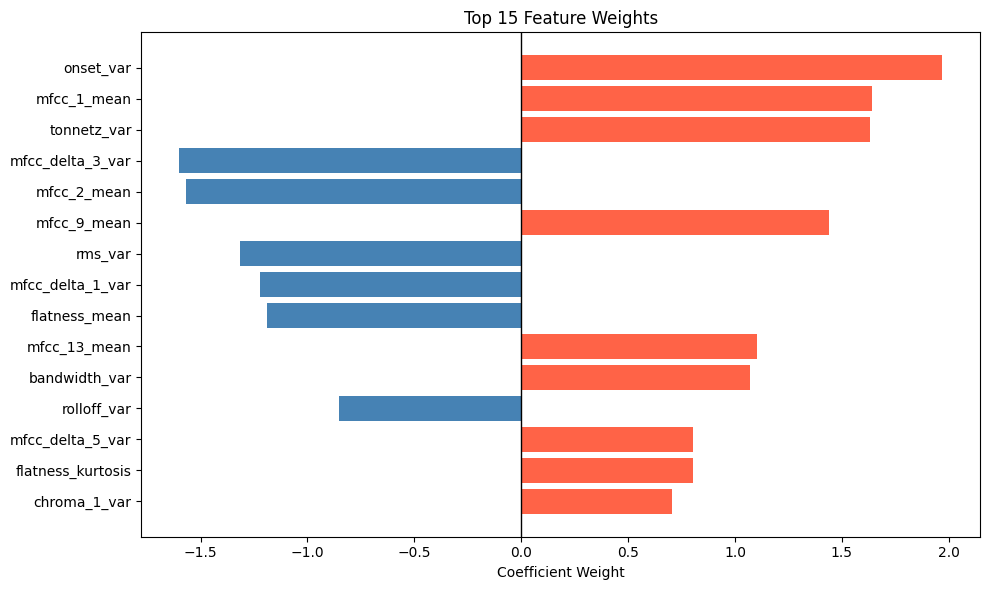


Top 15 features:

onset_var                        1.9679 -> AI
mfcc_1_mean                      1.6426 -> AI
tonnetz_var                      1.6320 -> AI
mfcc_delta_3_var                -1.5987 -> Human
mfcc_2_mean                     -1.5694 -> Human
mfcc_9_mean                      1.4414 -> AI
rms_var                         -1.3178 -> Human
mfcc_delta_1_var                -1.2211 -> Human
flatness_mean                   -1.1872 -> Human
mfcc_13_mean                     1.1035 -> AI
bandwidth_var                    1.0679 -> AI
rolloff_var                     -0.8541 -> Human
mfcc_delta_5_var                 0.8057 -> AI
flatness_kurtosis                0.8029 -> AI
chroma_1_var                     0.7062 -> AI


In [7]:
def show_top_features(n=15):

    import pandas as pd
    import matplotlib.pyplot as plt
    from sklearn.ensemble import VotingClassifier
    from sklearn.linear_model import LogisticRegression

    m = model

    # If ensemble, grab LR model
    if isinstance(m, VotingClassifier):

        for name, est in m.named_estimators_.items():

            if isinstance(est, LogisticRegression):
                m = est
                break

    # Logistic Regression
    if isinstance(m, LogisticRegression):

        weights = m.coef_[0]

        df = pd.DataFrame({
            "feature": feature_cols,
            "weight": weights
        })

        df["abs_weight"] = df["weight"].abs()

        df = df.sort_values(
            "abs_weight",
            ascending=False
        ).head(n)

        colors = [
            "tomato" if w > 0 else "steelblue"
            for w in df["weight"]
        ]

        plt.figure(figsize=(10, 6))

        plt.barh(
            df["feature"][::-1],
            df["weight"][::-1],
            color=colors[::-1]
        )

        plt.axvline(0, color="black", linewidth=1)

        plt.title(f"Top {n} Feature Weights")
        plt.xlabel("Coefficient Weight")

        plt.tight_layout()
        plt.show()

        print(f"\nTop {n} features:\n")

        for _, row in df.iterrows():

            direction = (
                "AI"
                if row["weight"] > 0
                else "Human"
            )

            print(
                f"{row['feature']:30s} "
                f"{row['weight']:>8.4f} "
                f"-> {direction}"
            )

    # Tree models
    elif hasattr(m, "feature_importances_"):

        df = pd.DataFrame({
            "feature": feature_cols,
            "importance": m.feature_importances_
        })

        df = df.sort_values(
            "importance",
            ascending=False
        ).head(n)

        plt.figure(figsize=(10, 6))

        plt.barh(
            df["feature"][::-1],
            df["importance"][::-1]
        )

        plt.title(f"Top {n} Feature Importances")
        plt.xlabel("Importance")

        plt.tight_layout()
        plt.show()

        print(df.to_string(index=False))

    else:

        print(
            f"{type(m).__name__} "
            f"does not support feature importance."
        )


show_top_features()

## Test a Single Song - Set a local path, then run.


In [1]:
SONG_PATH  = None # example: r'C:\path\to\song.mp3'
SONG_LABEL = None  # 'AI', 'Human', or None if unknown

if SONG_PATH:
    result = predict_song(SONG_PATH, actual=SONG_LABEL)
    visualize_song(SONG_PATH, result=result)
else:
    print('Set SONG_PATH to run a manual single-song test.')

Set SONG_PATH to run a manual single-song test.


## Test a Folder of Songs - Optional Manual Batch Inference


In [2]:
TEST_FOLDER = None  # example: r'C:\path\to\testing_music'

# If you know actual labels for files, add them here: filename -> 'AI' or 'Human'
ACTUALS = {
    # 'song1.mp3': 'AI',
    # 'song2.wav': 'Human',
}

all_results = []

if TEST_FOLDER and os.path.isdir(TEST_FOLDER):
    files = [f for f in os.listdir(TEST_FOLDER) if f.lower().endswith(('.mp3', '.wav', '.flac', '.m4a', '.ogg'))]
    print(f'Found {len(files)} audio files in folder.\n')

    for filename in sorted(files):
        filepath = os.path.join(TEST_FOLDER, filename)
        actual   = ACTUALS.get(filename, None)
        try:
            res = predict_song(filepath, actual=actual)
            all_results.append(res)
        except Exception as e:
            print(f'  ERROR on {filename}: {e}')
            all_results.append({
                'filename': filename, 'prediction': 'ERROR', 'P(AI)': None,
                'P(Human)': None, 'score_band': 'ERROR', 'AI_chunks': '0/0',
                'actual': actual or '?', 'correct': '-'
            })

    summary_cols = ['filename', 'prediction', 'P(AI)', 'P(Human)',
                    'score_band', 'AI_chunks', 'actual', 'correct']
    summary = pd.DataFrame(all_results)[summary_cols]

    print('\n' + '-'*70)
    print('RESULTS SUMMARY')
    print('-'*70)
    print(summary.to_string(index=False))

    known = summary[summary['actual'] != '?']
    if len(known) > 0:
        correct = (known['correct'] == 'Yes').sum()
        print(f'\nAccuracy on labelled files : {correct}/{len(known)} = {correct/len(known)*100:.1f}%')

    csv_path = os.path.join(TEST_FOLDER, 'test_results.csv')
    summary.to_csv(csv_path, index=False)
    print(f'\nSaved results: {csv_path}')
else:
    print('Set TEST_FOLDER to run optional batch inference.')

Set TEST_FOLDER to run optional batch inference.


In [9]:
# Held-out deployment-pipeline evaluation using the frozen 5s chunked dataset.
# This validates the deployed inference logic: predict each 5s chunk, average P(AI), then score at song level.
# It does not regenerate datasets and does not train a new model.

WINDOW_DATASET_PATH = 'FINAL_ai_human_music_detector_dataset.csv'
CHUNKED_DATASET_PATH = 'FINAL_ai_human_music_detector_dataset_CHUNKED.csv'
RUN_HELDOUT_CHUNK_EVAL = True

if RUN_HELDOUT_CHUNK_EVAL:
    df_song = pd.read_csv(WINDOW_DATASET_PATH)
    df_chunk = pd.read_csv(CHUNKED_DATASET_PATH).replace([np.inf, -np.inf], np.nan).dropna()

    _, df_test = train_test_split(
        df_song[['filename', 'label']],
        test_size=0.15,
        random_state=42,
        stratify=df_song['label']
    )
    heldout_files = set(df_test['filename'])
    df_eval = df_chunk[df_chunk['filename'].isin(heldout_files)].copy()

    if df_eval.empty:
        raise ValueError('No held-out filenames from the 30s split were found in the chunked dataset.')

    song_rows = []
    for filename, group in df_eval.groupby('filename'):
        X_chunks = scaler.transform(group[feature_cols].values)
        chunk_p_ai = model.predict_proba(X_chunks)[:, 1]
        avg_p_ai = float(np.mean(chunk_p_ai))
        y_true = int(group['label'].iloc[0])
        y_pred = int(avg_p_ai >= AI_THRESHOLD)
        song_rows.append({
            'filename': filename,
            'label': y_true,
            'prediction': y_pred,
            'P(AI)': avg_p_ai,
            'num_chunks': int(len(group)),
        })

    deployment_eval = pd.DataFrame(song_rows).sort_values('filename')
    acc = accuracy_score(deployment_eval['label'], deployment_eval['prediction'])
    auc = roc_auc_score(deployment_eval['label'], deployment_eval['P(AI)'])
    cm = confusion_matrix(deployment_eval['label'], deployment_eval['prediction'])

    print('HELD-OUT 5s DEPLOYMENT PIPELINE EVALUATION')
    print('-' * 60)
    print(f'Songs evaluated : {len(deployment_eval)}')
    print(f'Accuracy        : {acc*100:.1f}%')
    print(f'ROC-AUC         : {auc:.4f}')
    print('\nClassification report:')
    print(classification_report(deployment_eval['label'], deployment_eval['prediction'], target_names=['Human', 'AI'], zero_division=0))
    print('Confusion matrix [Human, AI]:')
    print(cm)

    deployment_eval.to_csv('deployment_5s_heldout_results.csv', index=False)
    print('\nSaved: deployment_5s_heldout_results.csv')
else:
    print('Set RUN_HELDOUT_CHUNK_EVAL = True to evaluate the frozen 5s chunked deployment pipeline.')

HELD-OUT 5s DEPLOYMENT PIPELINE EVALUATION
------------------------------------------------------------
Songs evaluated : 66
Accuracy        : 90.9%
ROC-AUC         : 0.9697

Classification report:
              precision    recall  f1-score   support

       Human       0.89      0.94      0.91        33
          AI       0.94      0.88      0.91        33

    accuracy                           0.91        66
   macro avg       0.91      0.91      0.91        66
weighted avg       0.91      0.91      0.91        66

Confusion matrix [Human, AI]:
[[31  2]
 [ 4 29]]

Saved: deployment_5s_heldout_results.csv
